In [8]:
import numpy as np 
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

In [22]:
my_data = pd.read_csv("rounded_values_int.csv", delimiter=",")
my_data[0:5]

,RSRP,RSSI,RSRQ,SNR,CINR,MOS,Rounded_MOS_normal
0,-100,-74.0,-199.000000,12.762571,10.097029,4.002256,4
1,-97,-67.0,-154.000000,16.509812,13.382265,3.957574,4
2,-91,-60.0,-167.078556,17.658596,14.177795,4.011303,4
3,-103,-59.0,-175.000000,16.772214,13.420014,3.735515,4
4,-114,-87.0,-251.900407,8.051354,5.350529,3.091996,3


In [24]:
X = my_data[['RSRP','RSSI','RSRQ','SNR','CINR']].values
X[0:5]


array([[-100.        ,  -74.        , -199.        ,   12.7625705 ,
          10.09702894],
       [ -97.        ,  -67.        , -154.        ,   16.50981178,
          13.38226477],
       [ -91.        ,  -60.        , -167.07855575,   17.65859585,
          14.17779467],
       [-103.        ,  -59.        , -175.        ,   16.77221405,
          13.42001427],
       [-114.        ,  -87.        , -251.9004071 ,    8.05135392,
           5.35052915]])

In [25]:
y = my_data["Rounded_MOS_normal"]
y[0:5]

0    4
1    4
2    4
3    4
4    3
Name: Rounded_MOS_normal, dtype: int64

<hr>

<div id="setting_up_tree">
    <h2>Setting up the Decision Tree</h2>
</div>


In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.2, random_state=1)

<hr>

<div id="modeling">
    <h2>Modeling</h2>
</div>


In [28]:
drugTree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
drugTree # it shows the default parameters

DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [29]:
drugTree.fit(X_trainset,y_trainset)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

<hr>

<div id="prediction">
    <h2>Prediction</h2>
</div>


In [30]:
example_sample=[[-85,-67.000000,-107.000000,12.703582,8.360441]]
drugTree.predict(example_sample)

array([4])

In [31]:
predTree = drugTree.predict(X_testset)
print (predTree [0:5])
print (y_testset [0:5])


[4 4 4 4 4]
2836    4
6258    4
5978    4
5007    4
3335    3
Name: Rounded_MOS_normal, dtype: int64


<hr>

<div id="evaluation">
    <h2>Evaluation</h2>
</div>


In [32]:
from sklearn import metrics
import matplotlib.pyplot as plt
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_testset, predTree))

DecisionTrees's Accuracy:  0.8685410334346505


<hr>

<div id="visualization">
    <h2>Visualization</h2>
</div>


In [33]:
from  io import StringIO
import pydotplus
import matplotlib.image as mpimg
from sklearn import tree
%matplotlib inline 

238     4
304     4
1528    4
2991    4
2375    4
       ..
905     4
5192    4
3980    4
235     4
5157    4
Name: Rounded_MOS_normal, Length: 5261, dtype: int64
[2 3 4 5]
['4', '3', '5', '2']


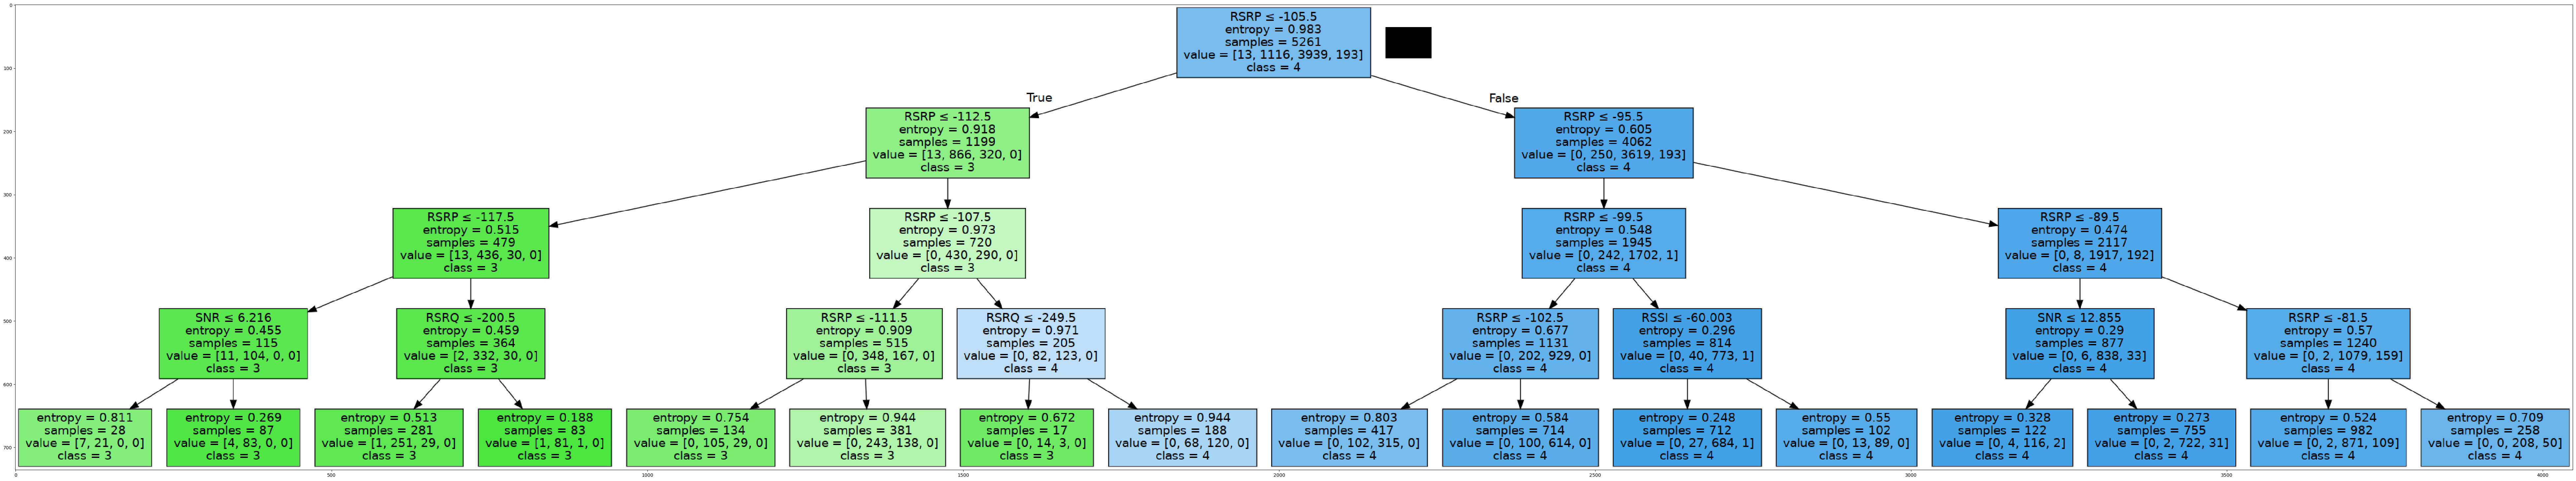

In [34]:
dot_data = StringIO()
filename = "drugtree.png"
featureNames = my_data.columns[0:5]
print(y_trainset)
y_trainset_str = np.array(y_trainset.unique()).astype('str').tolist()
print(np.unique(y_trainset))
print(y_trainset_str)
out=tree.export_graphviz(drugTree,feature_names=featureNames, out_file=dot_data, class_names= np.unique(y_trainset_str), filled=True,  special_characters=True,rotate=False)  
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png(filename)
img = mpimg.imread(filename)
plt.figure(figsize=(100, 200))
plt.imshow(img,interpolation='nearest')